In [1]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 26.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gurobipy as gp
from gurobipy import GRB

In [3]:
from google.colab import files

uploaded = files.upload()

Saving phase2_route_buffer_input_for_optimization.csv to phase2_route_buffer_input_for_optimization.csv


In [4]:
route_input_file = "phase2_route_buffer_input_for_optimization.csv"

route_df = pd.read_csv(route_input_file)

print("Shape:", route_df.shape)
route_df.head()

Shape: (68, 10)


,route,flights,avg_scheduled_elapsed_time,avg_actual_elapsed_time,avg_predicted_actual_elapsed_time,avg_predicted_block_time_gap,median_predicted_block_time_gap,p75_predicted_block_time_gap,mae_gradient_boosting,candidate_buffer_minutes
0,CLT-DCA,208,83.653846,84.067308,89.070822,5.416976,6.720070,9.279166,11.949376,5.416976
1,DCA-BOS,202,91.658416,92.153465,94.270401,2.611985,2.843057,4.115077,9.823389,2.611985
2,MCI-DCA,1,134.000000,132.000000,134.693333,0.693333,0.693333,0.693333,2.693333,0.693333
3,RDU-DCA,13,67.000000,61.923077,66.806751,-0.193249,-0.021228,-0.021228,6.783856,0.000000
4,JAX-DCA,60,113.666667,107.166667,113.415678,-0.250988,-0.511578,0.898238,9.524392,0.000000


In [5]:
opt_df = route_df.copy()

# Keep only routes with enough observations
MIN_FLIGHTS = 5

opt_df = opt_df[opt_df["flights"] >= MIN_FLIGHTS].copy()

# Define buffer need using 75th percentile predicted block-time gap
# Negative gaps mean no additional buffer is needed

opt_df["buffer_need_minutes"] = np.ceil(
    opt_df["p75_predicted_block_time_gap"].clip(lower=0)
).astype(int)

# Cap very large recommendations
MAX_BUFFER_PER_ROUTE = 15

opt_df["buffer_need_minutes"] = opt_df["buffer_need_minutes"].clip(
    upper=MAX_BUFFER_PER_ROUTE
)

# Only optimize routes that actually need buffer
opt_routes = opt_df[opt_df["buffer_need_minutes"] > 0].copy()

print("Routes used in optimization:", opt_routes.shape[0])

opt_routes[[
    "route",
    "flights",
    "avg_scheduled_elapsed_time",
    "avg_predicted_actual_elapsed_time",
    "p75_predicted_block_time_gap",
    "buffer_need_minutes"
]].head(10)

Routes used in optimization: 6


,route,flights,avg_scheduled_elapsed_time,avg_predicted_actual_elapsed_time,p75_predicted_block_time_gap,buffer_need_minutes
0,CLT-DCA,208,83.653846,89.070822,9.279166,10
1,DCA-BOS,202,91.658416,94.270401,4.115077,5
4,JAX-DCA,60,113.666667,113.415678,0.898238,1
5,ORD-DCA,146,114.493151,113.976470,2.045990,3
7,DCA-RDU,13,72.153846,71.079799,0.008851,1
10,RIC-DFW,85,216.776471,215.282661,1.010517,2


In [6]:
# Create route list

routes = opt_routes["route"].tolist()

# Parameters

flights = dict(zip(opt_routes["route"], opt_routes["flights"]))
buffer_need = dict(zip(opt_routes["route"], opt_routes["buffer_need_minutes"]))

# Total system-wide buffer need, weighted by number of flights

total_buffer_need = sum(flights[r] * buffer_need[r] for r in routes)

# Allow the optimizer to cover only part of the total need
# This prevents adding buffer everywhere

BUFFER_BUDGET_FRACTION = 0.60
total_buffer_budget = BUFFER_BUDGET_FRACTION * total_buffer_need

print("Total weighted buffer need:", total_buffer_need)
print("Allowed buffer budget:", round(total_buffer_budget, 2))

Total weighted buffer need: 3771
Allowed buffer budget: 2262.6


In [7]:
# Create Gurobi model

model = gp.Model("schedule_buffer_optimization")

# Decision variable:
# x[r] = additional buffer minutes assigned to route r

x = model.addVars(
    routes,
    vtype=GRB.INTEGER,
    lb=0,
    name="additional_buffer"
)

# Constraint 1:
# Buffer added to each route cannot exceed its estimated need

for r in routes:
    model.addConstr(
        x[r] <= buffer_need[r],
        name=f"max_buffer_{r}"
    )

# Constraint 2:
# Total added scheduled minutes across all flights cannot exceed budget

model.addConstr(
    gp.quicksum(flights[r] * x[r] for r in routes) <= total_buffer_budget,
    name="total_buffer_budget"
)

# Objective:
# Maximize reliability benefit
# Routes with more flights and larger buffer need are prioritized

model.setObjective(
    gp.quicksum(flights[r] * x[r] for r in routes),
    GRB.MAXIMIZE
)

# Solve model

model.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 7 rows, 6 columns and 12 nonzeros (Max)
Model fingerprint: 0x70651e41
Model has 6 linear objective coefficients
Variable types: 0 continuous, 6 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+01, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+03]

Found heuristic solution: objective 2238.0000000
Presolve removed 7 rows and 6 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 2 available processors)

Solution count 2: 2262 2238 

Optimal solution found (tolerance 1.00e-04)
Best 

In [8]:
# Store optimized buffer recommendation

recommended_buffer = {}

for r in routes:
    recommended_buffer[r] = int(round(x[r].X))

# Add recommendation back to the full route table

opt_df["recommended_buffer_minutes"] = opt_df["route"].map(recommended_buffer).fillna(0).astype(int)

# New scheduled block time after recommendation

opt_df["projected_scheduled_elapsed_time"] = (
    opt_df["avg_scheduled_elapsed_time"] + opt_df["recommended_buffer_minutes"]
)

# Total added scheduled minutes for each route

opt_df["total_added_scheduled_minutes"] = (
    opt_df["recommended_buffer_minutes"] * opt_df["flights"]
)

# Remaining unmet buffer need

opt_df["remaining_buffer_need_minutes"] = (
    opt_df["buffer_need_minutes"] - opt_df["recommended_buffer_minutes"]
).clip(lower=0)

opt_df[[
    "route",
    "flights",
    "avg_scheduled_elapsed_time",
    "avg_predicted_actual_elapsed_time",
    "buffer_need_minutes",
    "recommended_buffer_minutes",
    "projected_scheduled_elapsed_time",
    "remaining_buffer_need_minutes",
    "total_added_scheduled_minutes"
]].head(15)

,route,flights,avg_scheduled_elapsed_time,avg_predicted_actual_elapsed_time,buffer_need_minutes,recommended_buffer_minutes,projected_scheduled_elapsed_time,remaining_buffer_need_minutes,total_added_scheduled_minutes
0,CLT-DCA,208,83.653846,89.070822,10,6,89.653846,4,1248
1,DCA-BOS,202,91.658416,94.270401,5,4,95.658416,1,808
3,RDU-DCA,13,67.000000,66.806751,0,0,67.000000,0,0
4,JAX-DCA,60,113.666667,113.415678,1,1,114.666667,0,60
5,ORD-DCA,146,114.493151,113.976470,3,1,115.493151,2,146
6,BNA-DCA,35,106.914286,105.993626,0,0,106.914286,0,0
7,DCA-RDU,13,72.153846,71.079799,1,0,72.153846,1,0
8,MSY-DCA,32,146.593750,145.480214,0,0,146.593750,0,0
9,CHS-DCA,42,94.023810,92.550043,0,0,94.023810,0,0
10,RIC-DFW,85,216.776471,215.282661,2,0,216.776471,2,0


In [9]:
phase3_results = opt_df[[
    "route",
    "flights",
    "avg_scheduled_elapsed_time",
    "avg_predicted_actual_elapsed_time",
    "avg_predicted_block_time_gap",
    "p75_predicted_block_time_gap",
    "buffer_need_minutes",
    "recommended_buffer_minutes",
    "projected_scheduled_elapsed_time",
    "remaining_buffer_need_minutes",
    "total_added_scheduled_minutes"
]].copy()

# Sort by recommended buffer

phase3_results = phase3_results.sort_values(
    by="recommended_buffer_minutes",
    ascending=False
).reset_index(drop=True)

phase3_results.head(20)

,route,flights,avg_scheduled_elapsed_time,avg_predicted_actual_elapsed_time,avg_predicted_block_time_gap,p75_predicted_block_time_gap,buffer_need_minutes,recommended_buffer_minutes,projected_scheduled_elapsed_time,remaining_buffer_need_minutes,total_added_scheduled_minutes
0,CLT-DCA,208,83.653846,89.070822,5.416976,9.279166,10,6,89.653846,4,1248
1,DCA-BOS,202,91.658416,94.270401,2.611985,4.115077,5,4,95.658416,1,808
2,JAX-DCA,60,113.666667,113.415678,-0.250988,0.898238,1,1,114.666667,0,60
3,ORD-DCA,146,114.493151,113.976470,-0.516681,2.045990,3,1,115.493151,2,146
4,RDU-DCA,13,67.000000,66.806751,-0.193249,-0.021228,0,0,67.000000,0,0
5,BNA-DCA,35,106.914286,105.993626,-0.920660,-0.719854,0,0,106.914286,0,0
6,DCA-RDU,13,72.153846,71.079799,-1.074047,0.008851,1,0,72.153846,1,0
7,MSY-DCA,32,146.593750,145.480214,-1.113536,-0.830473,0,0,146.593750,0,0
8,CHS-DCA,42,94.023810,92.550043,-1.473766,-0.300695,0,0,94.023810,0,0
9,RIC-DFW,85,216.776471,215.282661,-1.493809,1.010517,2,0,216.776471,2,0


In [10]:
total_routes = phase3_results.shape[0]

routes_with_buffer = (phase3_results["recommended_buffer_minutes"] > 0).sum()

total_flights = phase3_results["flights"].sum()

total_added_minutes = phase3_results["total_added_scheduled_minutes"].sum()

avg_added_buffer_per_flight = total_added_minutes / total_flights

summary = pd.DataFrame({
    "Metric": [
        "Total routes analyzed",
        "Routes receiving buffer increase",
        "Total flights represented",
        "Total added scheduled minutes",
        "Average added buffer per flight"
    ],
    "Value": [
        total_routes,
        routes_with_buffer,
        total_flights,
        round(total_added_minutes, 2),
        round(avg_added_buffer_per_flight, 2)
    ]
})

summary

,Metric,Value
0,Total routes analyzed,66.0
1,Routes receiving buffer increase,4.0
2,Total flights represented,5632.0
3,Total added scheduled minutes,2262.0
4,Average added buffer per flight,0.4


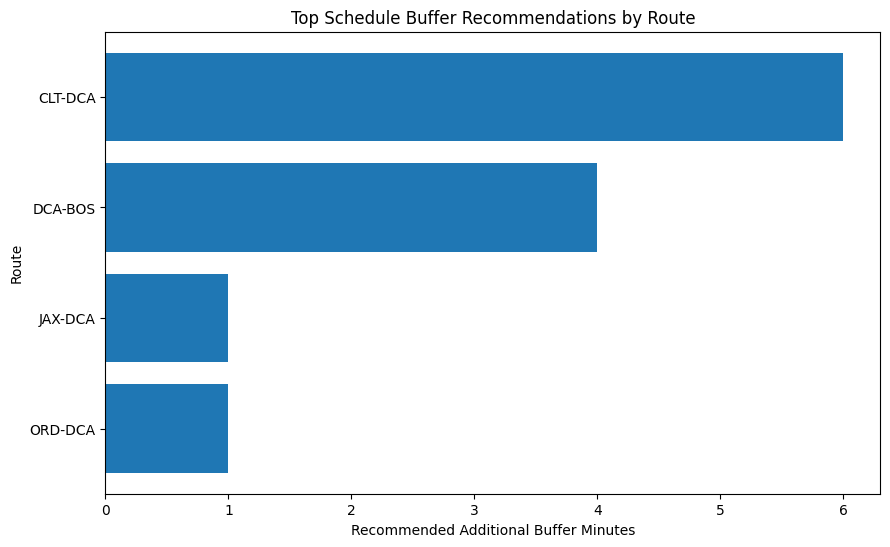

In [11]:
top_routes = phase3_results[
    phase3_results["recommended_buffer_minutes"] > 0
].head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_routes["route"], top_routes["recommended_buffer_minutes"])
plt.xlabel("Recommended Additional Buffer Minutes")
plt.ylabel("Route")
plt.title("Top Schedule Buffer Recommendations by Route")
plt.gca().invert_yaxis()
plt.show()

In [12]:
output_file = "phase3_route_schedule_buffer_optimization_results.csv"

phase3_results.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: phase3_route_schedule_buffer_optimization_results.csv


In [13]:
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In Phase 3, the Phase 2 Gradient Boosting predictions are used to support route-level schedule buffer decisions. For each route, the 75th percentile predicted block-time gap is used as the estimated buffer need. This focuses the analysis on reliability rather than only average performance.

A Gurobi optimization model is then used to recommend additional buffer minutes by route. The model maximizes total reliability benefit, weighted by the number of flights on each route, while limiting the total amount of additional scheduled minutes through a system-wide buffer budget. This prevents the model from simply adding buffer to every route.

The final output is a route-level table showing the estimated buffer need, recommended buffer increase, projected scheduled block time, remaining unmet need, and total added scheduled minutes.